# 이미지 데이터 분석기
각종 기능 등 테스트

## 1. 시각화 그래프 테스트

* 임베딩 벡터 분포 히스토그램
* 클러스터링 시각화

### 분포 히스토그램

In [3]:
import os
import torch
import clip
from PIL import Image

directory = './test_data'
formats = ['jpg', 'png', 'jpeg']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/16", device=device)
embeddings = []

for root, _, files in os.walk(directory):
            for file in files:
                if file.endswith(tuple(formats)):
                    file_path = os.path.join(root, file)
                    with Image.open(file_path) as img:
                        with torch.no_grad():
                            input = preprocess(img).unsqueeze(0).to(device)
                            embedding = model.encode_image(input).cpu().numpy().flatten()
                            embeddings.append(embedding.tolist())

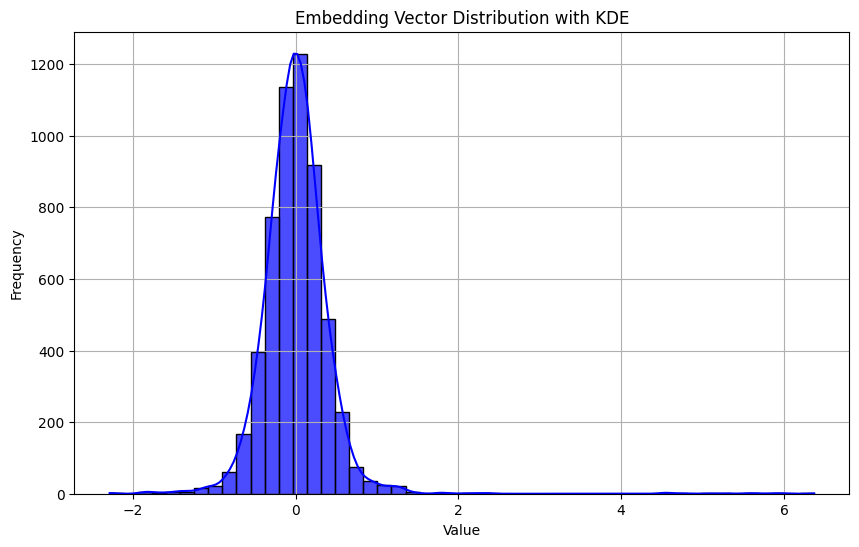

In [6]:
# 임베딩 벡터 분포 히스토그램 시각화
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Flatten the list of embeddings into a single array
flattened_embeddings = np.concatenate(embeddings)

plt.figure(figsize=(10, 6))
sns.histplot(flattened_embeddings, bins=50, color='blue', alpha=0.7, kde=True)
plt.title('Embedding Vector Distribution with KDE')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

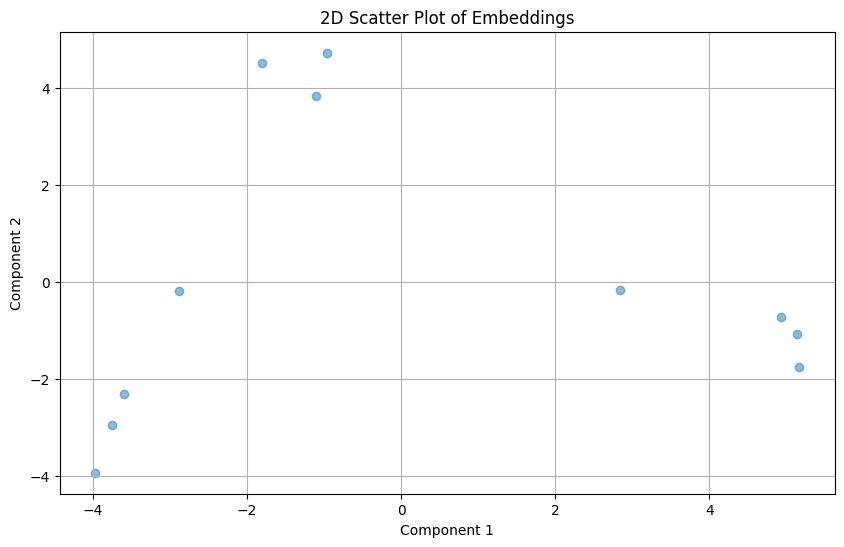

In [13]:
from sklearn.decomposition import PCA

# 차원 축소
embeddings_array = np.array(embeddings)
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings_array)

# 산점도
plt.figure(figsize=(10, 6))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], alpha=0.5)
plt.title('2D Scatter Plot of Embeddings')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True)
plt.show()

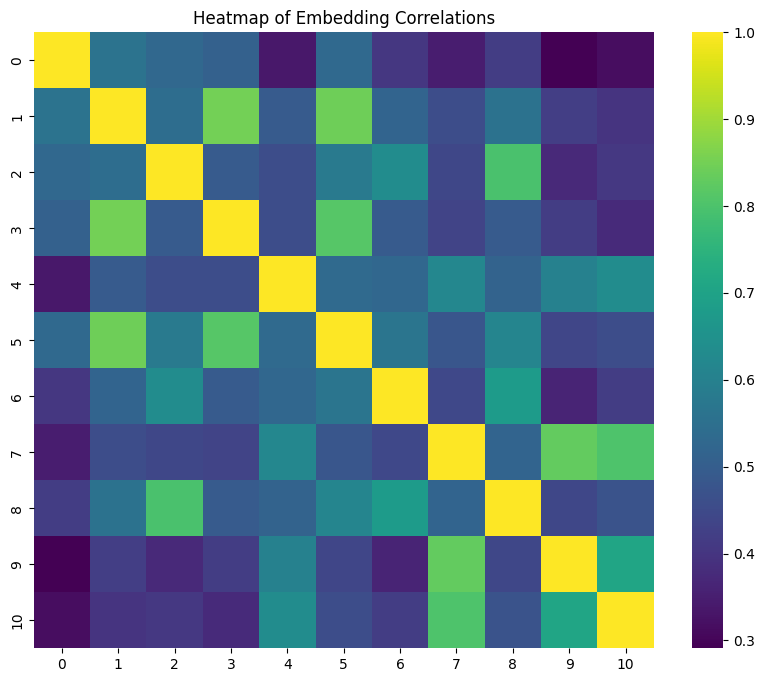

In [12]:
# 거리 행렬 계산
embeddings_array = np.array(embeddings)
distance_matrix = np.corrcoef(embeddings_array)

# 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, cmap='viridis')
plt.title('Heatmap of Embedding Correlations')
plt.show()